# Introduction

This notebook is an introduction to how to go about working with the Segment Anything Model(SAM). The pretrained models 

In [1]:
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import time

In [2]:
torch.cuda.empty_cache() 
# %env PYTORCH_CUDA_ALLOC_CONF=0:768
%env echo PYTORCH_CUDA_ALLOC_CONF

env: echo=PYTORCH_CUDA_ALLOC_CONF


In [3]:
def load_image(img_name, img_dir="testImages/"):
    return Image.open(img_dir+img_name).convert("RGB")  # load the image

# def compute_depth(image):    
#     depth_numpy = zoe.infer_pil(image)  # as numpy
#     return depth_numpy

def compare_maps(image, mask_map):
    colored_depth = colorize(depth_map)
    fig, axs = plt.subplots(1,2, figsize=(13,4))
    for ax, im, title in zip(axs, [image, colored_depth], ['Base Image', "Mask Map"]):
      ax.imshow(im)
      ax.axis("off")
      ax.set_title(title)

def plot_masks(mask_arr, score_arr):
    _, axs = plt.subplots(1,3, figsize=(13,4))
    for i in range(len(axs)):
        axs[i].imshow(mask_arr[i])
        axs[i].axis("off")
        axs[i].set_title( f"Score: { np.round(score_arr[i],3)} " )

# Setup Model

Segment Anything Model(SAM) offers 3 pre-trained models with difference backbone sizes. One can download any of them from their [github page](https://github.com/facebookresearch/segment-anything) for their own use. As in most cases, the bigger model gives accurate results but tend to be more compute intensive. That said, the PC in use ahas a 6GB GPU and more often than not I would get the following error 
>`CUDA out of memory. Tried to allocate 24.00 MiB (GPU 0; 5.80 GiB total capacity; 4.98 GiB already allocated; 47.75 MiB free; 5.08 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF`

<br/> Therefore the pretrained model in use is the sam_vit_l_0b3195.pth which is less powerful but works well with confoiguration being used. Using a CPU is also an option through specifing the `sam.to(device="cpu")` however it is too slow. For context, the cell below takes 15.729 secs with a CPU backend and 3.918 secs with the CUDA(GPU) backend. Other notable backends that could be used includeL ipy, opengl, openclm fpga, vulkan and hpu.

After instantiating the SAM predictor object, the target omage is set with `predictor.set_image(<image_as_np_array>)`

In [ ]:
start = time.time()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam_checkpoint = "Models/sam_vit_l_0b3195.pth"
model_type = "vit_l"

# Instntiate the model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=DEVICE)

img = np.asarray(load_image("33.jpg"))

predictor = SamPredictor(sam)


predictor.set_image(np.asarray(img))
print(f"Loading Time:{ time.time()-start }")

# Predict the Segmentation

SAM expects a prompt to work. For this case, a point within the image is considered. Specifically the center of the image as it is a fair assumption to assume that at least the central area of the image is occupied by the target object. If a point is provided, a label should also be provided,

Another input paramter of concern is that of the `multimask_output<bool>`. This is set to True as the docs recommend so for an amboiguous prompt like a single point. That way of the multiple results the best can be selected. The default options is however `True` so there is no need of explicitly setting it as such.

The returned objects of interest are:

    * A list of predicted masks
    * A list of the masks scores

The last return value is logits, which is a similar output to masks but with a fixed resolition of 256 by 256. This can be used for some further downstream processing.

In [ ]:
select_point = np.array([[img.shape[0]/2, img.shape[1]/2]])
masks, scores, _ = predictor.predict(
    point_coords=select_point, 
    point_labels=np.array([1])
)
del sam
torch.cuda.empty_cache()

map_index = list(scores).index(scores.max())
plt.imshow(masks[map_index] )
plt.title(f"Score : {str(scores.max())}")
plt.show()

In [4]:
def sam_predict(img, model_type="vit_l", model_checkpoint="sam_vit_l_0b3195.pth", backend="cpu" ):
    start = time.time()
    sam = sam_model_registry[model_type](checkpoint="./Models/"+model_checkpoint)
    sam.to(device=backend)
    predictor = SamPredictor(sam)
    predictor.set_image(np.asarray(img))
    
    # Point to Prompt
    select_point = np.array([[img.shape[0]/2, img.shape[1]/2]])
    
    # Segment Predictions
    masks, scores, _ = predictor.predict(
        point_coords=select_point, 
        point_labels=np.array([1])
    )
    
    del sam
    torch.cuda.empty_cache()
    
    plot_masks(masks, scores)
    
    map_index = list(scores).index(scores.max())
    mask_img = masks[map_index]
    plt.imshow( mask_img )
    plt.title(f"Score : {str(scores.max())}")
    plt.show()
    print(f"Computation took: {time.time()-start}s")
#     return mask_img

## Vit_h + CPU

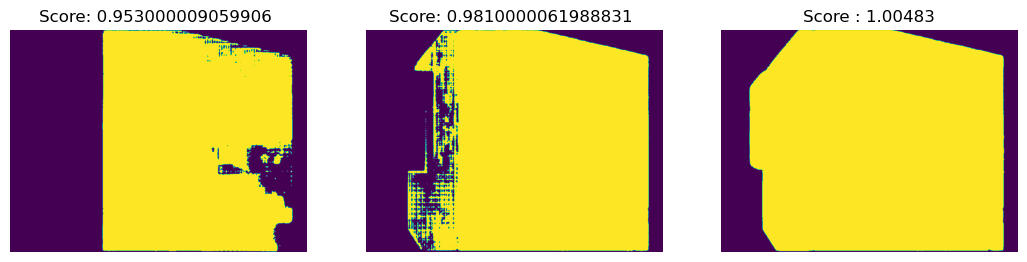

Computation took: 23.562798261642456s


In [5]:

# Clear any preloaded models and CUDA Cache
if 'sam' in locals() or 'sam' in globals() :
    del sam
    torch.cuda.empty_cache()
    
sam_predict( np.asarray(load_image("43.jpg")), model_type="vit_h",model_checkpoint="sam_vit_h_4b8939.pth"  )

## Vit_l + CPU

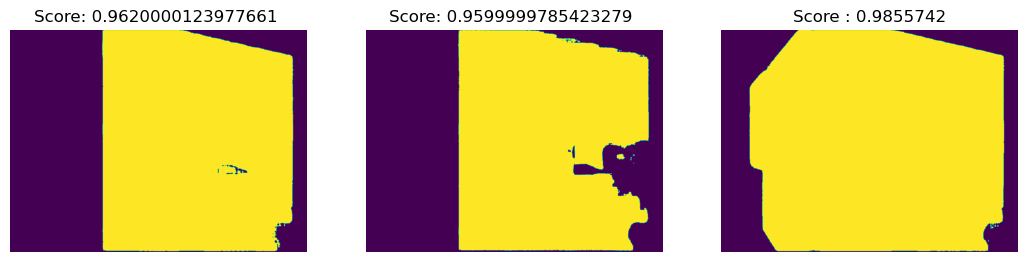

Computation took: 14.72471022605896s


In [6]:
# Clear any preloaded models and CUDA Cache
if 'sam' in locals() or 'sam' in globals():
    del sam
    torch.cuda.empty_cache()
    
sam_predict( np.asarray(load_image("43.jpg")))

## Vit_l + CUDA

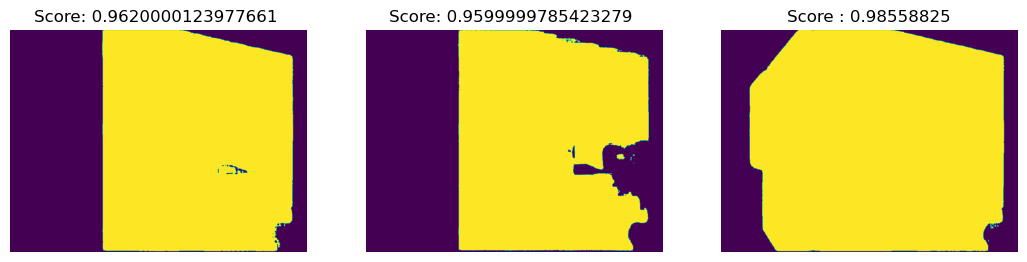

Computation took: 3.954211711883545s


In [7]:
# Clear any preloaded models and CUDA Cache
if 'sam' in locals() or 'sam' in globals():
    del sam
    torch.cuda.empty_cache()
    
sam_predict( np.asarray(load_image("43.jpg")), backend="cuda")

In [8]:
# Clear any preloaded models and CUDA Cache
if 'sam' in locals() or 'sam' in globals():
    del sam
    torch.cuda.empty_cache()
    
sam_predict( np.asarray(load_image("43.jpg")), model_type="vit_h",model_checkpoint="sam_vit_h_4b8939.pth", backend="cuda")

OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB (GPU 0; 5.80 GiB total capacity; 4.60 GiB already allocated; 825.69 MiB free; 4.78 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [1]:
import numpy as np
import pyvista as pv
pv.set_jupyter_backend('static')

sphere = pv.Sphere()
sphere.plot()


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations